In [2]:
#| echo: false

from IPython.display import Image, display, HTML

# Create HTML layout for side-by-side images
html_content = """
<div style="display: flex; gap: 20px;">
    <img src="https://ucarecdn.com/fe16e27c-a341-4551-9b84-e0e56bb2d329/-/stretch/off/-/resize/1100x/-/format/webp/" width="500" />
</div>
"""

# Display the images side by side
display(HTML(html_content))

## Introduction to Data Reshaping

Data reshaping involves transforming the **structure** of your data without changing the underlying information. Think of it like rearranging furniture in a room—the furniture stays the same, but its organization changes to suit different purposes.

In data analysis, the same dataset can be organized in different ways:

- **Wide format** spreads variables across multiple columns
- **Long format** stacks variables into fewer columns with more rows

Neither format is inherently "better"—the right format depends on what you're trying to accomplish.

### Why Data Reshaping Matters

**1. Different Tools Require Different Formats**

- **Visualization libraries** (like seaborn and matplotlib) often prefer long format for grouped plotting
- **Statistical models** may require wide format with one row per subject
- **Machine learning algorithms** typically need wide format where each row is an observation and columns are features

**2. Facilitates Specific Analyses**

- **Time series comparisons** are easier in wide format (comparing 2007 vs 1957 life expectancy)
- **Grouped aggregations** work naturally with long format
- **Cross-sectional analysis** benefits from wide format

**3. Simplifies Data Operations**

- Some calculations are trivial in one format but complex in another
- Merging datasets often requires matching formats
- Creating summary tables may need pivoting

### Understanding Wide vs. Long Format

Let's use a concrete example to understand these formats. Imagine we have life expectancy data for three countries across three years.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
# Create a simple example dataset in LONG format
long_data = pd.DataFrame({
    'Country': ['USA', 'USA', 'USA', 'Canada', 'Canada', 'Canada', 'Mexico', 'Mexico', 'Mexico'],
    'Year': [2000, 2005, 2010, 2000, 2005, 2010, 2000, 2005, 2010],
    'LifeExp': [76.8, 77.5, 78.5, 79.2, 80.1, 81.0, 74.1, 75.2, 76.5]
})

print("LONG FORMAT (Tidy Data):")
print("="*50)
print(long_data)
print("\nShape:", long_data.shape)
print("Characteristics: More rows, fewer columns, each observation is one row")

LONG FORMAT (Tidy Data):
  Country  Year  LifeExp
0     USA  2000     76.8
1     USA  2005     77.5
2     USA  2010     78.5
3  Canada  2000     79.2
4  Canada  2005     80.1
5  Canada  2010     81.0
6  Mexico  2000     74.1
7  Mexico  2005     75.2
8  Mexico  2010     76.5

Shape: (9, 3)
Characteristics: More rows, fewer columns, each observation is one row


In [5]:
# Convert to WIDE format
wide_data = long_data.pivot(index='Country', columns='Year', values='LifeExp')

print("\nWIDE FORMAT:")
print("="*50)
print(wide_data)
print("\nShape:", wide_data.shape)
print("Characteristics: Fewer rows, more columns, years spread across columns")


WIDE FORMAT:
Year     2000  2005  2010
Country                  
Canada   79.2  80.1  81.0
Mexico   74.1  75.2  76.5
USA      76.8  77.5  78.5

Shape: (3, 3)
Characteristics: Fewer rows, more columns, years spread across columns


**Key Observations:**

| Format | Rows | Columns | Use Case |
|--------|------|---------|----------|
| **Long** | 9 | 3 | Better for plotting with seaborn, groupby operations, statistical modeling |
| **Wide** | 3 | 3 (+index) | Better for comparing across years, reading tables, some statistical tests |

**Same data, different organization!** 


### Reshaping Tools in Pandas

Pandas provides several functions to reshape data between wide and long formats:

| Function | Direction | Primary Use |
|----------|-----------|-------------|
| **`pivot_table()`** | Long → Wide | Create summary tables with aggregation |
| **`melt()`** | Wide → Long | Unpivot columns into rows |
| **`stack()`** | Wide → Long | Move column index to row index (works with MultiIndex) |
| **`unstack()`** | Long → Wide | Move row index to column index (works with MultiIndex) |

In this chapter, we'll explore each method with practical examples using the *gdp_lifeExpectancy.csv* dataset. 

Let's start by reading the CSV file into a pandas DataFrame.

In [6]:
# Load the data
gdp_lifeExp_data = pd.read_csv('./Datasets/gdp_lifeExpectancy.csv')
gdp_lifeExp_data.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


## Pivoting from Long to Wide: `pivot_table()`

The `pivot_table()` function is one of pandas' most versatile tools—it serves a dual purpose as both an **aggregation tool** and a **data reshaping tool**. While you may have seen pivot tables in Excel for summarizing data, pandas' `pivot_table()` is even more powerful.

### What is Pivoting?

**Pivoting** transforms long format data into wide format by:

- Taking values from rows and spreading them **across columns**
- Creating a **cross-tabulation** structure that's easy to read
- Automatically **aggregating** when there are multiple values per group

Think of it as "pivoting" your data 90 degrees—what was vertical becomes horizontal.


Let's start with a simple example before moving to more complex scenarios.

### Example 1: Simple Pivot with Single Index

Let's start by pivoting life expectancy data to compare specific years. We'll create a table where continents are rows and years are columns.

In [7]:
# Simple pivot: continents as rows, years as columns
simple_pivot = gdp_lifeExp_data.pivot_table(
    index='continent',       # Rows
    columns='year',          # Columns
    values='lifeExp',        # Values to display
    aggfunc='mean'           # How to aggregate (mean life expectancy)
)

print("Mean Life Expectancy by Continent and Year:")
simple_pivot

Mean Life Expectancy by Continent and Year:


year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.135500,41.266346,43.319442,45.334538,47.450942,49.580423,51.592865,53.344788,53.629577,53.598269,53.325231,54.806038
Americas,53.279840,55.960280,58.398760,60.410920,62.394920,64.391560,66.228840,68.090720,69.568360,71.150480,72.422040,73.608120
Asia,46.314394,49.318544,51.563223,54.663640,57.319269,59.610556,62.617939,64.851182,66.537212,68.020515,69.233879,70.728485
Europe,64.408500,66.703067,68.539233,69.737600,70.775033,71.937767,72.806400,73.642167,74.440100,75.505167,76.700600,77.648600
Oceania,69.255000,70.295000,71.085000,71.310000,71.910000,72.855000,74.290000,75.320000,76.945000,78.190000,79.740000,80.719500


**Understanding the Parameters:**

- **`index='continent'`** - Values from this column become row labels
- **`columns='year'`** - Unique values from this column become column headers
- **`values='lifeExp'`** - The data to display in the table cells
- **`aggfunc='mean'`** - Since multiple countries exist per continent-year, we average them

**Result:** Each cell shows the mean life expectancy for a continent in a specific year. This wide format makes it easy to compare across years (reading horizontally across a row).

### Example 2: Multi-Level Index (Hierarchical Pivot)

Now let's create a more detailed pivot table with both continent and country as row indices. This creates a hierarchical structure that allows drill-down analysis.

In [8]:
# Multi-level pivot: both continent and country as row indices
gdp_lifeExp_data_pivot = gdp_lifeExp_data.pivot_table(
    index=['continent', 'country'],  # Two-level row index
    columns='year',                   # Years as columns
    values='lifeExp',                 # Life expectancy values
    aggfunc='mean'                    # Aggregation function
)

# Display first 10 rows
gdp_lifeExp_data_pivot.head(10)

year                                  1952    1957    1962    1967    1972  \
continent country                                                            
Africa    Algeria                   43.077  45.685  48.303  51.407  54.518   
          Angola                    30.015  31.999  34.000  35.985  37.928   
          Benin                     38.223  40.358  42.618  44.885  47.014   
          Botswana                  47.622  49.618  51.520  53.298  56.024   
          Burkina Faso              31.975  34.906  37.814  40.697  43.591   
          Burundi                   39.031  40.533  42.045  43.548  44.057   
          Cameroon                  38.523  40.428  42.643  44.799  47.049   
          Central African Republic  35.463  37.464  39.475  41.478  43.457   
          Chad                      38.092  39.881  41.716  43.601  45.569   
          Comoros                   40.715  42.460  44.467  46.472  48.944   

year                                  1977    1982    1987    1992    1997  \
continent country                                                            
Africa    Algeria                   58.014  61.368  65.799  67.744  69.152   
          Angola                    39.483  39.942  39.906  40.647  40.963   
          Benin                     49.190  50.904  52.337  53.919  54.777   
          Botswana                  59.319  61.484  63.622  62.745  52.556   
          Burkina Faso              46.137  48.122  49.557  50.260  50.324   
          Burundi                   45.910  47.471  48.211  44.736  45.326   
          Cameroon                  49.355  52.961  54.985  54.314  52.199   
          Central African Republic  46.775  48.295  50.485  49.396  46.066   
          Chad                      47.383  49.517  51.051  51.724  51.573   
          Comoros                   50.939  52.933  54.926  57.939  60.660   

year                                  2002    2007  
continent country                                   
Africa    Algeria                   70.994  72.301  
          Angola                    41.003  42.731  
          Benin                     54.406  56.728  
          Botswana                  46.634  50.728  
          Burkina Faso              50.650  52.295  
          Burundi                   47.360  49.580  
          Cameroon                  49.856  50.430  
          Central African Republic  43.308  44.741  
          Chad                      50.525  50.651  
          Comoros                   62.974  65.152

**Understanding Multi-Level Indices:**

When you pass a list to the `index` parameter, pandas creates a **hierarchical (multi-level) index**:

- **Level 0** (outermost): `continent` - Groups countries by continent
- **Level 1** (inner): `country` - Individual countries within each continent


**Benefits of this structure:**

- Easy to see all years for a country in one row
- Natural grouping by continent
- Facilitates comparisons across time periods

### Practical Use: Temporal Comparisons

With years as columns, comparing life expectancy across different time periods becomes trivial. Let's visualize how life expectancy changed over 50 years (1957 vs 2007).

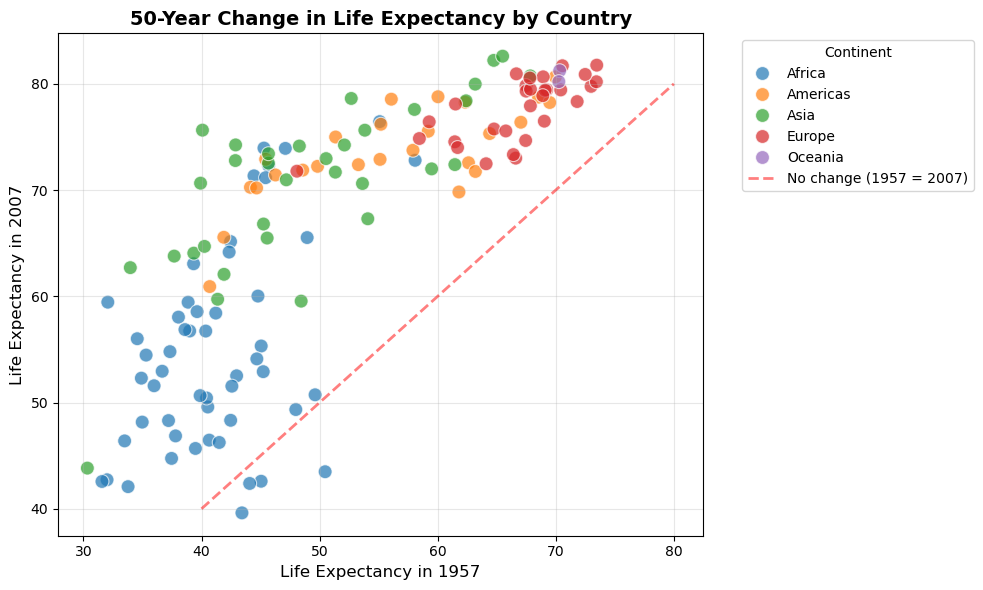

In [9]:
# Create a scatter plot comparing 1957 vs 2007 life expectancy
plt.figure(figsize=(10, 6))

# Add continent information for coloring
# Reset index to access 'continent' column for hue parameter
plot_data = gdp_lifeExp_data_pivot.reset_index()

# Create scatter plot
sns.scatterplot(data=plot_data, x=1957, y=2007, hue='continent', s=100, alpha=0.7)

# Add diagonal reference line (y = x) showing where 1957 = 2007
plt.plot([40, 80], [40, 80], 'r--', linewidth=2, label='No change (1957 = 2007)', alpha=0.5)

# Labels and formatting
plt.xlabel('Life Expectancy in 1957', fontsize=12)
plt.ylabel('Life Expectancy in 2007', fontsize=12)
plt.title('50-Year Change in Life Expectancy by Country', fontsize=14, fontweight='bold')
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the Visualization:**

- **Points above the red line**: Countries where life expectancy **increased** from 1957 to 2007 (most countries)
- **Points below the red line**: Countries where life expectancy **decreased** (concerning trend worth investigating)
- **Distance from the line**: Magnitude of change over the 50-year period

**Key Insight:** A few African countries show decreased life expectancy after 50 years, likely due to factors like HIV/AIDS epidemic, conflicts, or healthcare system challenges. This pattern would be harder to spot without the wide format pivot table!

### Visualizing Pivot Tables with Heatmaps

Another powerful way to visualize pivot tables is using **heatmaps**, which represent the table as a color-coded matrix. This makes it easy to spot patterns, trends, and outliers at a glance.

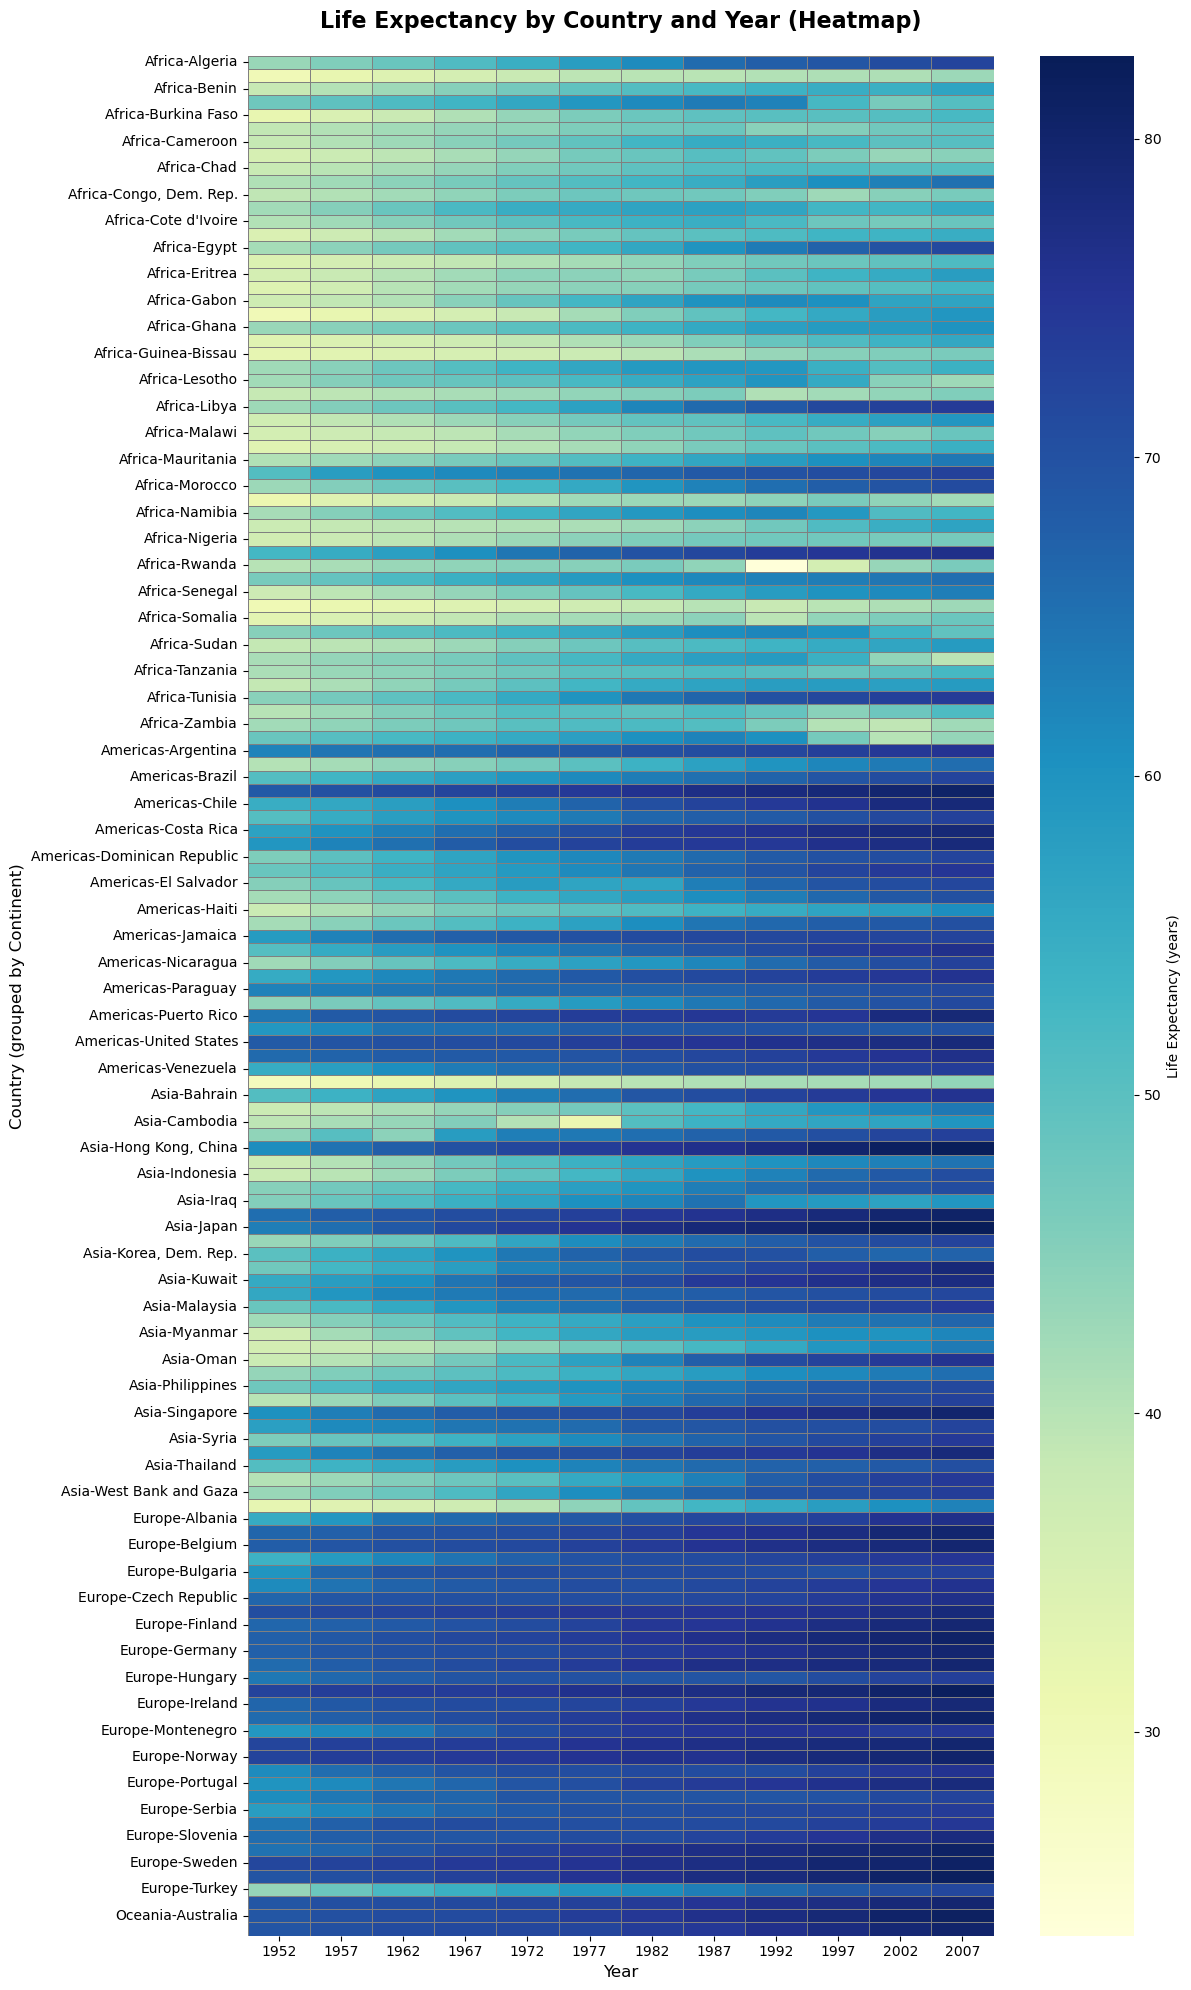

In [10]:
# Create a heatmap of the pivot table
plt.figure(figsize=(12, 20))
plt.title("Life Expectancy by Country and Year (Heatmap)", fontsize=16, fontweight='bold', pad=20)

# Create heatmap with better formatting
sns.heatmap(
    gdp_lifeExp_data_pivot, 
    cmap='YlGnBu',           # Yellow-Green-Blue color scheme
    cbar_kws={'label': 'Life Expectancy (years)'},
    linewidths=0.5,          # Add grid lines
    linecolor='gray',
    fmt='.1f'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Country (grouped by Continent)', fontsize=12)
plt.tight_layout()
plt.show()

**Reading the Heatmap:**

- **Darker (blue) colors** indicate higher life expectancy
- **Lighter (yellow) colors** indicate lower life expectancy
- **Horizontal patterns** show trends over time for individual countries
- **Vertical patterns** show disparities across countries in a specific year

**Patterns to Notice:**

1. General darkening from left to right = life expectancy increasing over time globally
2. Top rows (Oceania, Europe) consistently darker = higher life expectancy
3. Bottom rows (Africa) show more yellow = lower life expectancy, though improving

**Common Aggregation Functions in `pivot_table()`**

You can use various aggregation functions within `pivot_table()` to summarize data:

- **`mean`** – Calculates the average of values within each group.
- **`sum`** – Computes the total of values within each group.
- **`count`** – Counts the number of non-null entries within each group.
- **`min`** and **`max`** – Finds the minimum and maximum values within each group.

We can also define our own custom aggregation function and pass it to the `aggfunc` parameter of the `pivot_table()` function

**For Example:** Find the $90^{th}$ percentile of life expectancy for each country and year combination

In [11]:
pd.pivot_table(data = gdp_lifeExp_data, values = 'lifeExp',index = 'country', columns ='year',aggfunc = lambda x:np.percentile(x,90))

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
country,,,,,,,,,,,,
Afghanistan,28.801,30.332,31.997,34.020,36.088,38.438,39.854,40.822,41.674,41.763,42.129,43.828
Albania,55.230,59.280,64.820,66.220,67.690,68.930,70.420,72.000,71.581,72.950,75.651,76.423
Algeria,43.077,45.685,48.303,51.407,54.518,58.014,61.368,65.799,67.744,69.152,70.994,72.301
Angola,30.015,31.999,34.000,35.985,37.928,39.483,39.942,39.906,40.647,40.963,41.003,42.731
Argentina,62.485,64.399,65.142,65.634,67.065,68.481,69.942,70.774,71.868,73.275,74.340,75.320
...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,40.412,42.887,45.363,47.838,50.254,55.764,58.816,62.820,67.662,70.672,73.017,74.249
West Bank and Gaza,43.160,45.671,48.127,51.631,56.532,60.765,64.406,67.046,69.718,71.096,72.370,73.422
"Yemen, Rep.",32.548,33.970,35.180,36.984,39.848,44.175,49.113,52.922,55.599,58.020,60.308,62.698


Example: Consider the life expectancy dataset, calculate the average life expectancy for each country and year combination

In [12]:
pd.pivot_table(data = gdp_lifeExp_data, values = 'lifeExp',index = 'country', columns ='year',aggfunc = 'mean',margins = True)

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007,All
country,,,,,,,,,,,,,
Afghanistan,28.80100,30.332000,31.997000,34.02000,36.088000,38.438000,39.854000,40.822000,41.674000,41.763000,42.129000,43.828000,37.478833
Albania,55.23000,59.280000,64.820000,66.22000,67.690000,68.930000,70.420000,72.000000,71.581000,72.950000,75.651000,76.423000,68.432917
Algeria,43.07700,45.685000,48.303000,51.40700,54.518000,58.014000,61.368000,65.799000,67.744000,69.152000,70.994000,72.301000,59.030167
Angola,30.01500,31.999000,34.000000,35.98500,37.928000,39.483000,39.942000,39.906000,40.647000,40.963000,41.003000,42.731000,37.883500
Argentina,62.48500,64.399000,65.142000,65.63400,67.065000,68.481000,69.942000,70.774000,71.868000,73.275000,74.340000,75.320000,69.060417
...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,43.16000,45.671000,48.127000,51.63100,56.532000,60.765000,64.406000,67.046000,69.718000,71.096000,72.370000,73.422000,60.328667
"Yemen, Rep.",32.54800,33.970000,35.180000,36.98400,39.848000,44.175000,49.113000,52.922000,55.599000,58.020000,60.308000,62.698000,46.780417
Zambia,42.03800,44.077000,46.023000,47.76800,50.107000,51.386000,51.821000,50.821000,46.100000,40.238000,39.193000,42.384000,45.996333


## Melting from Wide to Long: `melt()`

**`melt()`** is the inverse operation of pivoting—it transforms **wide format** data into **long format** by "unpivoting" columns into rows. This is also called "melting" because you're "melting" wide columns down into a taller, narrower structure.

### Key Parameters

| Parameter | Description |
|------------|--------------|
| `id_vars` | Columns that remain as identifiers (not melted) |
| `value_vars` | Columns to unpivot (default: all except `id_vars`) |
| `var_name` | Name for the “variable” column |
| `value_name` | Name for the “value” column |


### Why Melt Your Data?

**Visualization Libraries Prefer Long Format:**

- Seaborn and many plotting tools expect data in long format
- Makes it easy to create grouped plots with `hue`, `style`, or `col` parameters

**Better for Statistical Analysis:**

- Long format is "tidy data"—each variable in one column, each observation in one row
- Required for many statistical models and tests

**More Flexible for groupby() Operations:**

- Easier to filter and aggregate when variables are in rows rather than column names

Let's see this in action!

### Example 1: Basic Melt

Let's take our pivoted data (wide format) and melt it back to long format. First, let's look at what we're starting with:

In [13]:
# Let's look at our wide format data (first 5 rows)
print(f"\nShape: {gdp_lifeExp_data_pivot.shape}")
print("Notice: Years are columns (wide), each country is one row")

print("WIDE FORMAT (pivoted data):")
print("="*60)
gdp_lifeExp_data_pivot.head()


Shape: (142, 12)
Notice: Years are columns (wide), each country is one row
WIDE FORMAT (pivoted data):


year                      1952    1957    1962    1967    1972    1977  \
continent country                                                        
Africa    Algeria       43.077  45.685  48.303  51.407  54.518  58.014   
          Angola        30.015  31.999  34.000  35.985  37.928  39.483   
          Benin         38.223  40.358  42.618  44.885  47.014  49.190   
          Botswana      47.622  49.618  51.520  53.298  56.024  59.319   
          Burkina Faso  31.975  34.906  37.814  40.697  43.591  46.137   

year                      1982    1987    1992    1997    2002    2007  
continent country                                                       
Africa    Algeria       61.368  65.799  67.744  69.152  70.994  72.301  
          Angola        39.942  39.906  40.647  40.963  41.003  42.731  
          Benin         50.904  52.337  53.919  54.777  54.406  56.728  
          Botswana      61.484  63.622  62.745  52.556  46.634  50.728  
          Burkina Faso  48.122  49.557  50.260  50.324  50.650  52.295

In [14]:
# Melt the wide format back to long format
melted_data = gdp_lifeExp_data_pivot.melt(
    var_name='year',          # Name for the column that will hold year values
    value_name='lifeExp',     # Name for the column that will hold life expectancy values
    ignore_index=False        # Keep the original index (continent, country)
)

print(f"\nShape: {melted_data.shape}")
print("Notice: Years are now rows (long), multiple rows per country")


print("\nLONG FORMAT (after melting):")
print("="*60)
melted_data.head(15)  # Show more rows to see the pattern


Shape: (1704, 2)
Notice: Years are now rows (long), multiple rows per country

LONG FORMAT (after melting):


year  lifeExp
continent country                                
Africa    Algeria                   1952   43.077
          Angola                    1952   30.015
          Benin                     1952   38.223
          Botswana                  1952   47.622
          Burkina Faso              1952   31.975
          Burundi                   1952   39.031
          Cameroon                  1952   38.523
          Central African Republic  1952   35.463
          Chad                      1952   38.092
          Comoros                   1952   40.715
          Congo, Dem. Rep.          1952   39.143
          Congo, Rep.               1952   42.111
          Cote d'Ivoire             1952   40.477
          Djibouti                  1952   34.812
          Egypt                     1952   41.893

**What Just Happened?**

1. **Wide Format** (before melt):
   - 142 rows × 12 columns (one column per year)
   - Each country had one row with year values spread across columns
   
2. **Long Format** (after melt):
   - 1,704 rows × 1 column (142 countries × 12 years = 1,704 rows)
   - Each country-year combination gets its own row
   - The `year` column now contains what were previously column headers
   - The `lifeExp` column contains the actual values

**Key Parameters Used:**

- `var_name='year'` - Column header values (1952, 1957, etc.) go into a new column called 'year'
- `value_name='lifeExp'` - Cell values go into a new column called 'lifeExp'
- `ignore_index=False` - Preserve the multi-level index (continent, country)

This is now in **tidy format**, perfect for plotting and analysis!

### Example 2: Using Melted Data for Visualization

Now that we have data in long format, we can easily create time series plots grouped by continent. This would be much harder with wide format data!

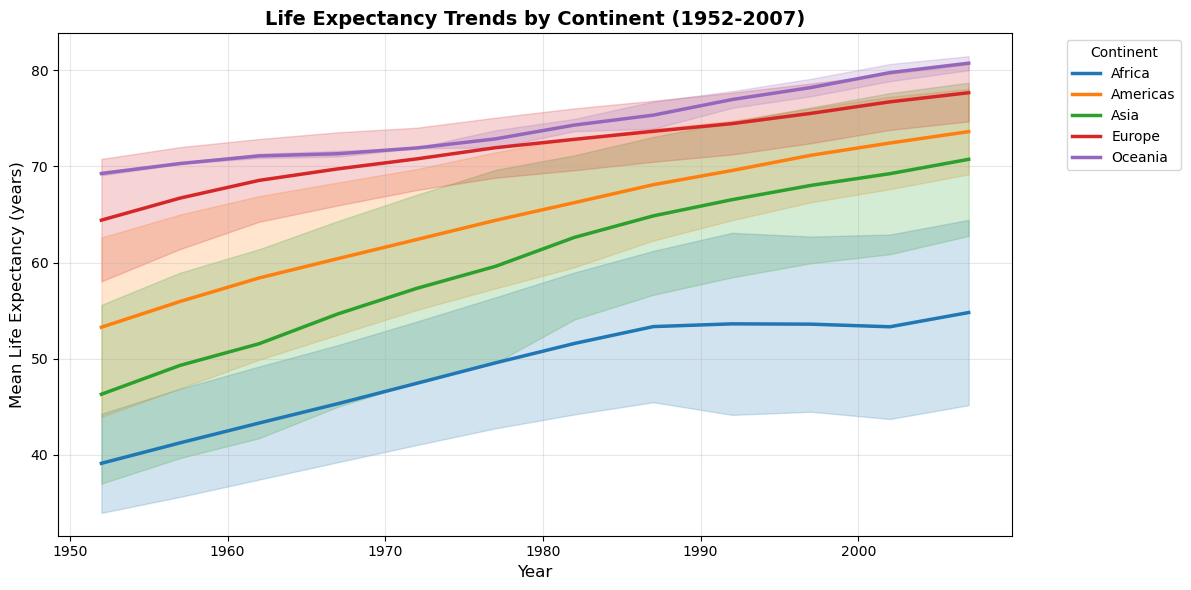

In [15]:
# Prepare data for plotting by resetting index to access continent column
plot_data = melted_data.reset_index()

# Create a line plot showing life expectancy trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_data, 
    x='year', 
    y='lifeExp', 
    hue='continent',
    estimator='mean',       # Average across countries in each continent
    errorbar='sd',          # Show standard deviation as error bars
    linewidth=2.5
)

plt.title('Life Expectancy Trends by Continent (1952-2007)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Life Expectancy (years)', fontsize=12)
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Why This Works So Well:**

This visualization would be extremely difficult with wide format data! With long format:

- Seaborn automatically groups by continent using the `hue` parameter
- The `x='year'` and `y='lifeExp'` mappings are straightforward
- Error bars show variation across countries within each continent

**Key Insights from the Plot:**

- All continents show upward trends (global improvement in healthcare)
- Oceania maintains the highest life expectancy throughout
- Africa starts lowest but shows improvement
- The gap between continents has narrowed over time (error bars converge)

This is the power of having data in the right format!

### Pivot ↔ Melt: The Full Circle

Let's verify that `pivot_table()` and `melt()` are truly inverse operations by starting with long format, pivoting to wide, then melting back to long:

In [16]:
# Step 1: Start with original long format data
print("Step 1 - ORIGINAL (Long Format):")
print(f"Shape: {gdp_lifeExp_data.shape}")
print(gdp_lifeExp_data.head(3))

# Step 2: Pivot to wide format
wide = gdp_lifeExp_data.pivot_table(
    index=['continent', 'country'], 
    columns='year', 
    values='lifeExp'
)
print("\n" + "="*60)
print("Step 2 - PIVOTED (Wide Format):")
print(f"Shape: {wide.shape}")
print(wide.head(3))

# Step 3: Melt back to long format
long_again = wide.melt(var_name='year', value_name='lifeExp', ignore_index=False).reset_index()
print("\n" + "="*60)
print("Step 3 - MELTED BACK (Long Format):")
print(f"Shape: {long_again.shape}")
print(long_again.head(3))

print("\n✓ We're back where we started! pivot_table() and melt() are inverses.")

Step 1 - ORIGINAL (Long Format):
Shape: (1704, 6)
       country continent  year  lifeExp       pop   gdpPercap
0  Afghanistan      Asia  1952   28.801   8425333  779.445314
1  Afghanistan      Asia  1957   30.332   9240934  820.853030
2  Afghanistan      Asia  1962   31.997  10267083  853.100710

Step 2 - PIVOTED (Wide Format):
Shape: (142, 12)
year                 1952    1957    1962    1967    1972    1977    1982  \
continent country                                                           
Africa    Algeria  43.077  45.685  48.303  51.407  54.518  58.014  61.368   
          Angola   30.015  31.999  34.000  35.985  37.928  39.483  39.942   
          Benin    38.223  40.358  42.618  44.885  47.014  49.190  50.904   

year                 1987    1992    1997    2002    2007  
continent country                                          
Africa    Algeria  65.799  67.744  69.152  70.994  72.301  
          Angola   39.906  40.647  40.963  41.003  42.731  
          Benin    52.337 

## Stacking and Unstacking using `stack()` and `unstack()`

Stacking and unstacking are powerful techniques used to reshape DataFrames by moving data between rows and columns. These operations are particularly useful when working with **multi-level index** or **multi-level columns**, where the data is structured in a hierarchical format.

* `stack()`: Converts columns into rows, which means it "stacks" the data into a long format.
* `unstack()`: Converts rows into columns, reversing the effect of `stack()`.

Let’s use the GDP per capita dataset and create a DataFrame with a multi-level index (e.g., continent, country) and multi-level columns (e.g., lifeExp , gdpPercap, and pop).

In [17]:
# calculate the average and standard deviation of life expectancy, population, and GDP per capita for countries across the years.

gdp_lifeExp_multilevel_data = gdp_lifeExp_data.groupby(['continent', 'country'])[['lifeExp', 'pop', 'gdpPercap']].agg(['mean', 'std'])
gdp_lifeExp_multilevel_data

lifeExp                      pop                \
                               mean        std          mean           std   
continent country                                                            
Africa    Algeria         59.030167  10.340069  1.987541e+07  8.613355e+06   
          Angola          37.883500   4.005276  7.309390e+06  2.672281e+06   
          Benin           48.779917   6.128681  4.017497e+06  2.105002e+06   
          Botswana        54.597500   5.929476  9.711862e+05  4.710965e+05   
          Burkina Faso    44.694000   6.845792  7.548677e+06  3.247808e+06   
...                             ...        ...           ...           ...   
Europe    Switzerland     75.565083   4.011572  6.384293e+06  8.582009e+05   
          Turkey          59.696417   9.030591  4.590901e+07  1.667768e+07   
          United Kingdom  73.922583   3.378943  5.608780e+07  3.174339e+06   
Oceania   Australia       74.662917   4.147774  1.464931e+07  3.915203e+06   
          New Zealand     73.989500   3.559724  3.100032e+06  6.547108e+05   

                             gdpPercap               
                                  mean          std  
continent country                                    
Africa    Algeria          4426.025973  1310.337656  
          Angola           3607.100529  1165.900251  
          Benin            1155.395107   159.741306  
          Botswana         5031.503557  4178.136987  
          Burkina Faso      843.990665   183.430087  
...                                ...          ...  
Europe    Switzerland     27074.334405  6886.463308  
          Turkey           4469.453380  2049.665102  
          United Kingdom  19380.472986  7388.189399  
Oceania   Australia       19980.595634  7815.405220  
          New Zealand     17262.622813  4409.009167  

[142 rows x 6 columns]

The resulting DataFrame has two levels of index and two levels of columns, as shown below:

In [18]:
# check the level of row and column index
gdp_lifeExp_multilevel_data.index.nlevels

2

In [19]:
gdp_lifeExp_multilevel_data.columns.nlevels

2

if you want to see the data along with the index and columns (in a more accessible way), you can directly print the `.index` and `.columns` attributes.

In [20]:
gdp_lifeExp_multilevel_data.index

MultiIndex([( 'Africa',                  'Algeria'),
            ( 'Africa',                   'Angola'),
            ( 'Africa',                    'Benin'),
            ( 'Africa',                 'Botswana'),
            ( 'Africa',             'Burkina Faso'),
            ( 'Africa',                  'Burundi'),
            ( 'Africa',                 'Cameroon'),
            ( 'Africa', 'Central African Republic'),
            ( 'Africa',                     'Chad'),
            ( 'Africa',                  'Comoros'),
            ...
            ( 'Europe',                   'Serbia'),
            ( 'Europe',          'Slovak Republic'),
            ( 'Europe',                 'Slovenia'),
            ( 'Europe',                    'Spain'),
            ( 'Europe',                   'Sweden'),
            ( 'Europe',              'Switzerland'),
            ( 'Europe',                   'Turkey'),
            ( 'Europe',           'United Kingdom'),
            ('Oceania',       

In [21]:
gdp_lifeExp_multilevel_data.columns

MultiIndex([(  'lifeExp', 'mean'),
            (  'lifeExp',  'std'),
            (      'pop', 'mean'),
            (      'pop',  'std'),
            ('gdpPercap', 'mean'),
            ('gdpPercap',  'std')],
           )

As seen, **the index and columns each contain tuples**. This is the reason that when performing data subsetting on a DataFrame with multi-level index and columns, you need to supply a tuple to specify the exact location of the data.

In [22]:
gdp_lifeExp_multilevel_data.loc[('Americas', 'United States'), ('lifeExp', 'mean')]

73.4785

In [23]:
gdp_lifeExp_multilevel_data.columns.values

array([('lifeExp', 'mean'), ('lifeExp', 'std'), ('pop', 'mean'),
       ('pop', 'std'), ('gdpPercap', 'mean'), ('gdpPercap', 'std')],
      dtype=object)

### Understanding the `level` in multi-level index and columns

The `gdp_lifeExp_multilevel_data` dataframe have two levels of index and two level of columns, You can reference these levels in various operations, such as grouping, subsetting, or performing aggregations. The `level` parameter helps identify which part of the multi-level structure you're working with.

In [24]:
gdp_lifeExp_multilevel_data.index.get_level_values(0)

Index(['Africa', 'Africa', 'Africa', 'Africa', 'Africa', 'Africa', 'Africa',
       'Africa', 'Africa', 'Africa',
       ...
       'Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe',
       'Europe', 'Oceania', 'Oceania'],
      dtype='object', name='continent', length=142)

In [25]:
gdp_lifeExp_multilevel_data.index.get_level_values(1)

Index(['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
       'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
       ...
       'Serbia', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland', 'Turkey', 'United Kingdom', 'Australia', 'New Zealand'],
      dtype='object', name='country', length=142)

In [26]:
gdp_lifeExp_multilevel_data.columns.get_level_values(0)

Index(['lifeExp', 'lifeExp', 'pop', 'pop', 'gdpPercap', 'gdpPercap'], dtype='object')

In [27]:
gdp_lifeExp_multilevel_data.columns.get_level_values(1)

Index(['mean', 'std', 'mean', 'std', 'mean', 'std'], dtype='object')

In [28]:
gdp_lifeExp_multilevel_data.columns.get_level_values(-1)

Index(['mean', 'std', 'mean', 'std', 'mean', 'std'], dtype='object')

As seen above, the outermost level corresponds to `level=0`, and it increases as we move inward to the inner levels. The innermost level can be referred to as `-1`.

Now, let's use the level number in the `droplevel()` method to see how it works. The syntax for this method is as follows:

`DataFrame.droplevel(level, axis=0)`

In [29]:
# drop the first level of row index
gdp_lifeExp_multilevel_data.droplevel(0, axis=0)

lifeExp                      pop                \
                     mean        std          mean           std   
country                                                            
Algeria         59.030167  10.340069  1.987541e+07  8.613355e+06   
Angola          37.883500   4.005276  7.309390e+06  2.672281e+06   
Benin           48.779917   6.128681  4.017497e+06  2.105002e+06   
Botswana        54.597500   5.929476  9.711862e+05  4.710965e+05   
Burkina Faso    44.694000   6.845792  7.548677e+06  3.247808e+06   
...                   ...        ...           ...           ...   
Switzerland     75.565083   4.011572  6.384293e+06  8.582009e+05   
Turkey          59.696417   9.030591  4.590901e+07  1.667768e+07   
United Kingdom  73.922583   3.378943  5.608780e+07  3.174339e+06   
Australia       74.662917   4.147774  1.464931e+07  3.915203e+06   
New Zealand     73.989500   3.559724  3.100032e+06  6.547108e+05   

                   gdpPercap               
                        mean          std  
country                                    
Algeria          4426.025973  1310.337656  
Angola           3607.100529  1165.900251  
Benin            1155.395107   159.741306  
Botswana         5031.503557  4178.136987  
Burkina Faso      843.990665   183.430087  
...                      ...          ...  
Switzerland     27074.334405  6886.463308  
Turkey           4469.453380  2049.665102  
United Kingdom  19380.472986  7388.189399  
Australia       19980.595634  7815.405220  
New Zealand     17262.622813  4409.009167  

[142 rows x 6 columns]

In [30]:
# drop the first level of column index
gdp_lifeExp_multilevel_data.droplevel(0, axis=1)

mean        std          mean           std  \
continent country                                                            
Africa    Algeria         59.030167  10.340069  1.987541e+07  8.613355e+06   
          Angola          37.883500   4.005276  7.309390e+06  2.672281e+06   
          Benin           48.779917   6.128681  4.017497e+06  2.105002e+06   
          Botswana        54.597500   5.929476  9.711862e+05  4.710965e+05   
          Burkina Faso    44.694000   6.845792  7.548677e+06  3.247808e+06   
...                             ...        ...           ...           ...   
Europe    Switzerland     75.565083   4.011572  6.384293e+06  8.582009e+05   
          Turkey          59.696417   9.030591  4.590901e+07  1.667768e+07   
          United Kingdom  73.922583   3.378943  5.608780e+07  3.174339e+06   
Oceania   Australia       74.662917   4.147774  1.464931e+07  3.915203e+06   
          New Zealand     73.989500   3.559724  3.100032e+06  6.547108e+05   

                                  mean          std  
continent country                                    
Africa    Algeria          4426.025973  1310.337656  
          Angola           3607.100529  1165.900251  
          Benin            1155.395107   159.741306  
          Botswana         5031.503557  4178.136987  
          Burkina Faso      843.990665   183.430087  
...                                ...          ...  
Europe    Switzerland     27074.334405  6886.463308  
          Turkey           4469.453380  2049.665102  
          United Kingdom  19380.472986  7388.189399  
Oceania   Australia       19980.595634  7815.405220  
          New Zealand     17262.622813  4409.009167  

[142 rows x 6 columns]

### Stacking (Columns to Rows ): `stack()`

The `stack()` function pivots the columns into rows. You can specify which level you want to stack using the `level` parameter. By default, it will stack the innermost level of the columns.

In [31]:
gdp_lifeExp_multilevel_data.stack(future_stack=True)

lifeExp           pop     gdpPercap
continent country                                                   
Africa    Algeria        mean  59.030167  1.987541e+07   4426.025973
                         std   10.340069  8.613355e+06   1310.337656
          Angola         mean  37.883500  7.309390e+06   3607.100529
                         std    4.005276  2.672281e+06   1165.900251
          Benin          mean  48.779917  4.017497e+06   1155.395107
...                                  ...           ...           ...
Europe    United Kingdom std    3.378943  3.174339e+06   7388.189399
Oceania   Australia      mean  74.662917  1.464931e+07  19980.595634
                         std    4.147774  3.915203e+06   7815.405220
          New Zealand    mean  73.989500  3.100032e+06  17262.622813
                         std    3.559724  6.547108e+05   4409.009167

[284 rows x 3 columns]

Let's change the default setting by specifying the `level=0`(the outmost level)

In [32]:
gdp_lifeExp_multilevel_data.stack(level=0, future_stack=True)

mean           std
continent country                                          
Africa    Algeria     lifeExp    5.903017e+01  1.034007e+01
                      pop        1.987541e+07  8.613355e+06
                      gdpPercap  4.426026e+03  1.310338e+03
          Angola      lifeExp    3.788350e+01  4.005276e+00
                      pop        7.309390e+06  2.672281e+06
...                                       ...           ...
Oceania   Australia   pop        1.464931e+07  3.915203e+06
                      gdpPercap  1.998060e+04  7.815405e+03
          New Zealand lifeExp    7.398950e+01  3.559724e+00
                      pop        3.100032e+06  6.547108e+05
                      gdpPercap  1.726262e+04  4.409009e+03

[426 rows x 2 columns]

### Unstacking (Rows to Columns) : `unstack()`

The `unstack()` function pivots the rows back into columns. By default, it will unstack the innermost level of the index.

Let's reverse the prevous dataframe to its original shape using `unstack()`.

In [33]:
gdp_lifeExp_multilevel_data.stack(level=0, future_stack=True).unstack()

mean                                    std  \
                            lifeExp           pop     gdpPercap    lifeExp   
continent country                                                            
Africa    Algeria         59.030167  1.987541e+07   4426.025973  10.340069   
          Angola          37.883500  7.309390e+06   3607.100529   4.005276   
          Benin           48.779917  4.017497e+06   1155.395107   6.128681   
          Botswana        54.597500  9.711862e+05   5031.503557   5.929476   
          Burkina Faso    44.694000  7.548677e+06    843.990665   6.845792   
...                             ...           ...           ...        ...   
Europe    Switzerland     75.565083  6.384293e+06  27074.334405   4.011572   
          Turkey          59.696417  4.590901e+07   4469.453380   9.030591   
          United Kingdom  73.922583  5.608780e+07  19380.472986   3.378943   
Oceania   Australia       74.662917  1.464931e+07  19980.595634   4.147774   
          New Zealand     73.989500  3.100032e+06  17262.622813   3.559724   

                                                     
                                   pop    gdpPercap  
continent country                                    
Africa    Algeria         8.613355e+06  1310.337656  
          Angola          2.672281e+06  1165.900251  
          Benin           2.105002e+06   159.741306  
          Botswana        4.710965e+05  4178.136987  
          Burkina Faso    3.247808e+06   183.430087  
...                                ...          ...  
Europe    Switzerland     8.582009e+05  6886.463308  
          Turkey          1.667768e+07  2049.665102  
          United Kingdom  3.174339e+06  7388.189399  
Oceania   Australia       3.915203e+06  7815.405220  
          New Zealand     6.547108e+05  4409.009167  

[142 rows x 6 columns]

### Transposing using  `.T` attribute

If you simply want to swap rows and columns, you can use the `.T` attribute.

In [34]:
gdp_lifeExp_multilevel_data.T

continent             Africa                                             \
country              Algeria        Angola         Benin       Botswana   
lifeExp   mean  5.903017e+01  3.788350e+01  4.877992e+01      54.597500   
          std   1.034007e+01  4.005276e+00  6.128681e+00       5.929476   
pop       mean  1.987541e+07  7.309390e+06  4.017497e+06  971186.166667   
          std   8.613355e+06  2.672281e+06  2.105002e+06  471096.527435   
gdpPercap mean  4.426026e+03  3.607101e+03  1.155395e+03    5031.503557   
          std   1.310338e+03  1.165900e+03  1.597413e+02    4178.136987   

continent                                                 \
country         Burkina Faso       Burundi      Cameroon   
lifeExp   mean  4.469400e+01  4.481733e+01  4.812850e+01   
          std   6.845792e+00  3.174882e+00  5.467960e+00   
pop       mean  7.548677e+06  4.651608e+06  9.816648e+06   
          std   3.247808e+06  1.874538e+06  4.363640e+06   
gdpPercap mean  8.439907e+02  4.716630e+02  1.774634e+03   
          std   1.834301e+02  9.932972e+01  4.195899e+02   

continent                                                             ...  \
country        Central African Republic          Chad        Comoros  ...   
lifeExp   mean             4.386692e+01  4.677358e+01      52.381750  ...   
          std              4.720690e+00  4.887978e+00       8.132353  ...   
pop       mean             2.560963e+06  5.329256e+06  361683.916667  ...   
          std              1.072158e+06  2.464304e+06  182998.737990  ...   
gdpPercap mean             9.587847e+02  1.165454e+03    1314.380339  ...   
          std              1.919529e+02  2.305481e+02     298.334389  ...   

continent             Europe                                              \
country               Serbia Slovak Republic      Slovenia         Spain   
lifeExp   mean  6.855100e+01    7.069608e+01  7.160075e+01  7.420342e+01   
          std   4.906736e+00    2.715787e+00  3.677979e+00  5.155859e+00   
pop       mean  8.783887e+06    4.774507e+06  1.794381e+06  3.585180e+07   
          std   1.192153e+06    6.425096e+05  2.022077e+05  4.323928e+06   
gdpPercap mean  9.305049e+03    1.041553e+04  1.407458e+04  1.402983e+04   
          std   3.829907e+03    3.650231e+03  6.470288e+03  8.046635e+03   

continent                                                                \
country               Sweden   Switzerland        Turkey United Kingdom   
lifeExp   mean  7.617700e+01  7.556508e+01  5.969642e+01   7.392258e+01   
          std   3.003990e+00  4.011572e+00  9.030591e+00   3.378943e+00   
pop       mean  8.220029e+06  6.384293e+06  4.590901e+07   5.608780e+07   
          std   6.365660e+05  8.582009e+05  1.667768e+07   3.174339e+06   
gdpPercap mean  1.994313e+04  2.707433e+04  4.469453e+03   1.938047e+04   
          std   7.723248e+03  6.886463e+03  2.049665e+03   7.388189e+03   

continent            Oceania                
country            Australia   New Zealand  
lifeExp   mean  7.466292e+01  7.398950e+01  
          std   4.147774e+00  3.559724e+00  
pop       mean  1.464931e+07  3.100032e+06  
          std   3.915203e+06  6.547108e+05  
gdpPercap mean  1.998060e+04  1.726262e+04  
          std   7.815405e+03  4.409009e+03  

[6 rows x 142 columns]

## Summary of Common Reshaping Functions

| Function      | Description                                               | Example                            |
|---------------|-----------------------------------------------------------|------------------------------------|
| `pivot()`     | Reshape data by creating new columns from existing ones.  | Pivot data on index/columns.      |
| `melt()`      | Unpivot data, turning columns into rows.                  | Convert wide format to long.      |
| `stack()`     | Convert columns to rows.                                  | Move column data to rows.         |
| `unstack()`   | Convert rows back to columns.                             | Move row data to columns.         |
| `.T`          | Transpose the DataFrame (swap rows and columns).          | Transpose the entire DataFrame.   |

 **Practical Use Cases:**

- **Pivoting:** Useful for time series analysis or when you want to group and summarize data by specific categories.
- **Melting:** Helpful when you need to reshape wide data for easier analysis or when preparing data for machine learning algorithms.
- **Stacking/Unstacking:** Useful when you are working with hierarchical index DataFrames.
- **Transpose:** Helpful for reorienting data for analysis or visualization.

## Converting from Multi-Level Index to Single-Level Index DataFrame

If you're uncomfortable working with DataFrames that have multi-level indexes and columns, you can convert them into single-level DataFrames using the methods you learned in the previous chapter:

* `reset_index()`
* Flattening the multi-level columns

In [35]:
# reset the index to convert the multi-level index to a single-level index
gdp_lifeExp_multilevel_data.reset_index()

continent         country    lifeExp                      pop  \
                                    mean        std          mean   
0      Africa         Algeria  59.030167  10.340069  1.987541e+07   
1      Africa          Angola  37.883500   4.005276  7.309390e+06   
2      Africa           Benin  48.779917   6.128681  4.017497e+06   
3      Africa        Botswana  54.597500   5.929476  9.711862e+05   
4      Africa    Burkina Faso  44.694000   6.845792  7.548677e+06   
..        ...             ...        ...        ...           ...   
137    Europe     Switzerland  75.565083   4.011572  6.384293e+06   
138    Europe          Turkey  59.696417   9.030591  4.590901e+07   
139    Europe  United Kingdom  73.922583   3.378943  5.608780e+07   
140   Oceania       Australia  74.662917   4.147774  1.464931e+07   
141   Oceania     New Zealand  73.989500   3.559724  3.100032e+06   

                      gdpPercap               
              std          mean          std  
0    8.613355e+06   4426.025973  1310.337656  
1    2.672281e+06   3607.100529  1165.900251  
2    2.105002e+06   1155.395107   159.741306  
3    4.710965e+05   5031.503557  4178.136987  
4    3.247808e+06    843.990665   183.430087  
..            ...           ...          ...  
137  8.582009e+05  27074.334405  6886.463308  
138  1.667768e+07   4469.453380  2049.665102  
139  3.174339e+06  19380.472986  7388.189399  
140  3.915203e+06  19980.595634  7815.405220  
141  6.547108e+05  17262.622813  4409.009167  

[142 rows x 8 columns]

In [36]:
# flatten the multi-level column
gdp_lifeExp_multilevel_data.columns = ['_'.join(col).strip() for col in gdp_lifeExp_multilevel_data.columns.values]
gdp_lifeExp_multilevel_data

lifeExp_mean  lifeExp_std      pop_mean  \
continent country                                                   
Africa    Algeria            59.030167    10.340069  1.987541e+07   
          Angola             37.883500     4.005276  7.309390e+06   
          Benin              48.779917     6.128681  4.017497e+06   
          Botswana           54.597500     5.929476  9.711862e+05   
          Burkina Faso       44.694000     6.845792  7.548677e+06   
...                                ...          ...           ...   
Europe    Switzerland        75.565083     4.011572  6.384293e+06   
          Turkey             59.696417     9.030591  4.590901e+07   
          United Kingdom     73.922583     3.378943  5.608780e+07   
Oceania   Australia          74.662917     4.147774  1.464931e+07   
          New Zealand        73.989500     3.559724  3.100032e+06   

                               pop_std  gdpPercap_mean  gdpPercap_std  
continent country                                                      
Africa    Algeria         8.613355e+06     4426.025973    1310.337656  
          Angola          2.672281e+06     3607.100529    1165.900251  
          Benin           2.105002e+06     1155.395107     159.741306  
          Botswana        4.710965e+05     5031.503557    4178.136987  
          Burkina Faso    3.247808e+06      843.990665     183.430087  
...                                ...             ...            ...  
Europe    Switzerland     8.582009e+05    27074.334405    6886.463308  
          Turkey          1.667768e+07     4469.453380    2049.665102  
          United Kingdom  3.174339e+06    19380.472986    7388.189399  
Oceania   Australia       3.915203e+06    19980.595634    7815.405220  
          New Zealand     6.547108e+05    17262.622813    4409.009167  

[142 rows x 6 columns]

## Independent Study 


### Preparing GDP per capita data

Read the GDP per capita data from https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)_per_capita

Drop all the `Year` columns. Use the [`drop()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) method with the `columns`, `level` and `inplace` arguments. Print the first 2 rows of the updated DataFrame. If the first row of the DataFrame has missing values for all columns, drop that row as well.


#### 
Drop the inner level of column labels. Use the `droplevel()` method. Print the first 2 rows of the updated DataFrame.


#### 
Convert the columns consisting of GDP per capita by *IMF, World Bank*, and the *United Nations* to numeric. Apply a lambda function on these columns to convert them to numeric. Print the number of missing values in each column of the updated DataFrame.

Note: *Do not apply the function 3 times. Apply it once on a DataFrame consisting of these 3 columns.*



#### 
Apply the lambda function below on all the column names of the dataset obtained in the previous question to clean the column names.

`import re`

`column_name_cleaner = lambda x:re.split(r'\[|/', x)[0]`

*Note: You will need to edit the parameter of the function, i.e., `x` in the above function to make sure it is applied on column names and not columns.*

Print the first 2 rows of the updated DataFrame.



#### 
Create a new column `GDP_per_capita` that copies the GDP per capita values of the `United Nations`. If the GDP per capita is missing in the `United Nations` column, then copy it from the `World Bank` column. If the GDP per capita is missing both in the `United Nations` and the `World Bank` columns, then copy it from the `IMF` column. 

Print the number of missing values in the `GDP_per_capita` column.



####  
Drop all the columns except `Country` and `GDP_per_capita`. Print the first 2 rows of the updated DataFrame. 



#### 
The country names contain some special characters *(characters other than letters)* and need to be cleaned. The following function can help clean country names:

```import re```


```country_names_clean_gdp_data = lambda x: re.sub(r'[^\w\s]', '', x).strip()```

Apply the above lambda function on the country column to clean country names. Save the cleaned dataset as `gdp_per_capita_data`. Print the first 2 rows of the updated DataFrame.



### Preparing population data

Read the population data from https://en.wikipedia.org/wiki/List_of_countries_by_population_(United_Nations).

* Drop all columns except `Country`, `UN Continental Region[1]`, and `Population (1 July 2023)`.
* Drop the first row since it is the total population in the world


#### 
Apply the lambda function below on all the column names of the dataset obtained in the previous question to clean the column names.

`import re`

`column_name_cleaner = lambda x:re.split(r'\[|/|\(| ', x.name)[0]`

*Note: You will need to edit the parameter of the function, i.e., `x` in the above function to make sure it is applied on column names and not columns.*

Print the first 2 rows of the updated DataFrame.


####  
The country names contain some special characters *(characters other than letters)* and need to be cleaned. The following function can help clean country names:

```import re```

```country_names_clean_population_data = lambda x: re.sub("[\(\[].*?[\)\]]", "", x).strip()```

Apply the above lambda function on the country column to clean country names. Save the cleaned dataset as `population_data`.
